# Sprint 1 : Acquisition & Exploratory Data Analysis (EDA)

**AquaSense AI - EHTP MIG S4 - Contexte Maroc**

Ce notebook explore le dataset proxy **Pump It Up** (Tanzanie) avant modélisation.
Le **problème visé** est la maintenance des forages/points d'eau au **Maroc** : voir `reports/choix_dataset_maroc.md`.

Objectifs :
- Fusion train_values + train_labels
- Audit anomalies, imbalance, corrélations
- Problem Statement (cadrage Maroc) + justification du dataset proxy
- Contexte methodologique

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Dossier raw : {RAW_DIR}")

Racine projet : C:\Users\MOH\Documents\AquaSense_AI
Dossier raw : C:\Users\MOH\Documents\AquaSense_AI\data\raw


## 1. Chargement et fusion des données (S1-01)

Jointure sur `id` entre les features (`train_values`) et les labels (`train_labels`).

In [2]:
train_values = pd.read_csv(RAW_DIR / "train_values.csv")
train_labels = pd.read_csv(RAW_DIR / "train_labels.csv")
test_values = pd.read_csv(RAW_DIR / "test_values.csv")

print("train_values :", train_values.shape)
print("train_labels :", train_labels.shape)
print("test_values :", test_values.shape)

assert train_values["id"].duplicated().sum() == 0, "Doublons dans train_values"
assert train_labels["id"].duplicated().sum() == 0, "Doublons dans train_labels"

df_train = train_values.merge(train_labels, on="id", how="inner", validate="one_to_one")
print(f"\nDataFrame unifié df_train : {df_train.shape}")
assert len(df_train) == len(train_values), "Perte de lignes lors du merge"
df_train.head()

train_values : (59400, 40)
train_labels : (59400, 2)
test_values : (14850, 40)

DataFrame unifié df_train : (59400, 41)


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


**Analyse :** le merge est bijectif (59 400 lignes conservées). Chaque pompe possède exactement un label `status_group`.

## 2. Audit des valeurs manquantes (S1-02)

In [3]:
missing = df_train.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_train) * 100).round(1)
missing_report = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_report = missing_report[missing_report["missing"] > 0]

print("=== Top colonnes avec NaN ===")
display(missing_report.head(15))

=== Top colonnes avec NaN ===


,missing,pct
scheme_name,28810,48.5
scheme_management,3878,6.5
installer,3655,6.2
funder,3637,6.1
public_meeting,3334,5.6
permit,3056,5.1
subvillage,371,0.6
wpt_name,2,0.0


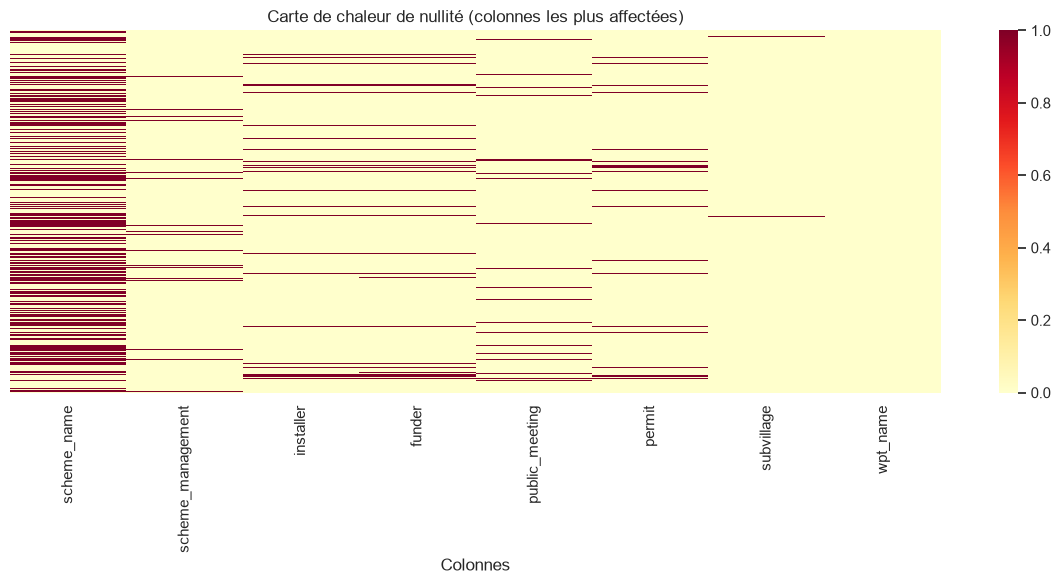

In [4]:
cols_with_nan = missing_report.index.tolist()
sample_cols = cols_with_nan[:12] if len(cols_with_nan) >= 12 else cols_with_nan

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
 df_train[sample_cols].isna(),
 cbar=True,
 yticklabels=False,
 cmap="YlOrRd",
 ax=ax,
)
ax.set_title("Carte de chaleur de nullité (colonnes les plus affectées)")
ax.set_xlabel("Colonnes")
plt.tight_layout()
plt.show()

**Analyse :**
- `scheme_name` est quasi-vide (~48,5 % NaN) -> candidat à la suppression (S2).
- `funder`, `installer`, `public_meeting` ont ~3 000-3 600 NaN -> imputation ou catégorie « unknown ».
- Les features numériques principales (`amount_tsh`, `gps_height`) n'ont pas de NaN explicites, mais des **zéros codés** (voir section 4).

## 3. Distribution de la cible (S1-03)

,count,pct
status_group,,
functional,32259,54.3
non functional,22824,38.4
functional needs repair,4317,7.3


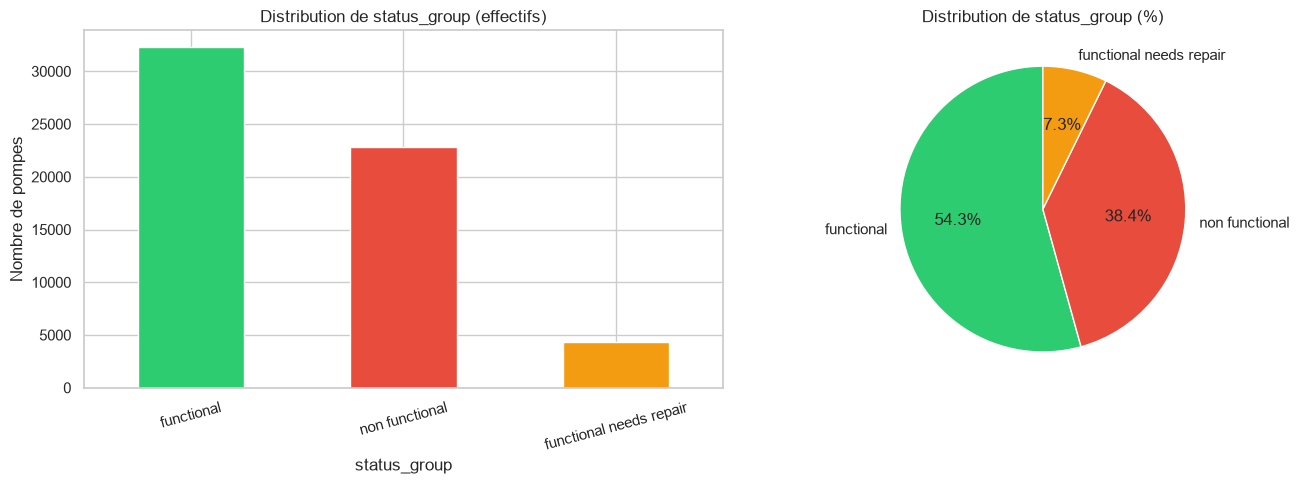

In [5]:
target_counts = df_train["status_group"].value_counts()
target_pct = df_train["status_group"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({"count": target_counts, "pct": target_pct.round(1)})
display(target_summary)

colors = {"functional": "#2ecc71", "functional needs repair": "#f39c12", "non functional": "#e74c3c"}
palette = [colors[c] for c in target_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_counts.plot.bar(ax=axes[0], color=palette, edgecolor="white")
axes[0].set_title("Distribution de status_group (effectifs)")
axes[0].set_ylabel("Nombre de pompes")
axes[0].tick_params(axis="x", rotation=15)

target_pct.plot.pie(ax=axes[1], autopct="%.1f%%", colors=palette, startangle=90)
axes[1].set_title("Distribution de status_group (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

**Analyse : imbalance sévère :**
| Classe | ~Part |
|--------|-------|
| `functional` | 54 % |
| `non functional` | 39 % |
| `functional needs repair` | **7 %** |

La classe métier la plus critique (`needs repair`) est **7× plus rare** que `functional`. Un modèle naïf qui prédit toujours « functional » obtiendrait ~54 % d'accuracy mais un recall nul sur les pompes à réparer.

**Stratégie d'imbalance retenue pour S3 :**
1. `class_weight='balanced'` pour LR et Random Forest
2. `scale_pos_weight` / poids de classe pour XGBoost
3. SMOTE en option si le recall « needs repair » reste < 0,65
4. Métriques prioritaires : **F1-Macro** et **recall par classe** (pas l'accuracy seule)

## 4. Variables numériques (S1-04)

Histogrammes et boxplots pour `amount_tsh`, `gps_height`, `population`, `construction_year`, plus détection des valeurs aberrantes.

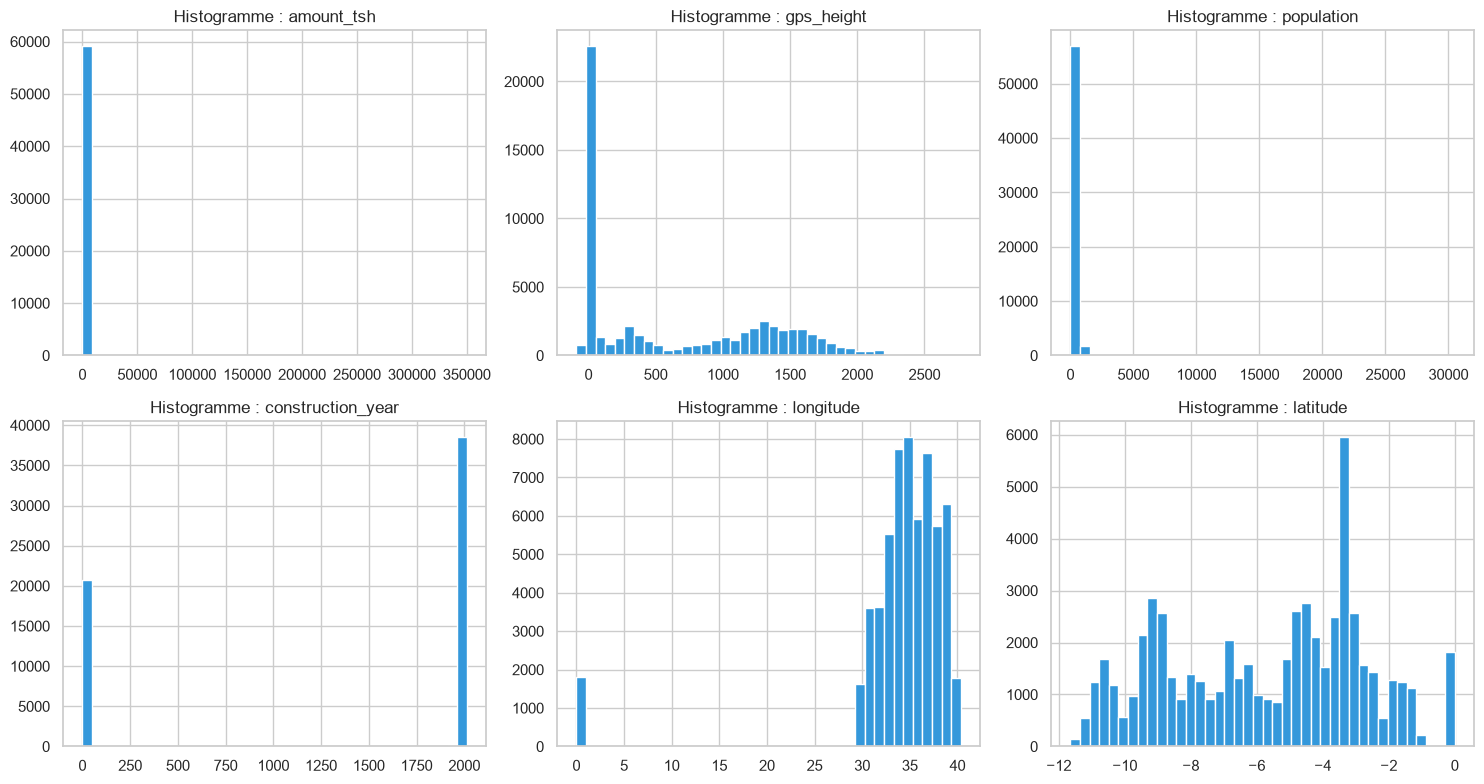

In [6]:
numeric_cols = ["amount_tsh", "gps_height", "population", "construction_year", "longitude", "latitude"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
 df_train[col].hist(ax=ax, bins=40, color="#3498db", edgecolor="white")
 ax.set_title(f"Histogramme : {col}")
plt.tight_layout()
plt.show()

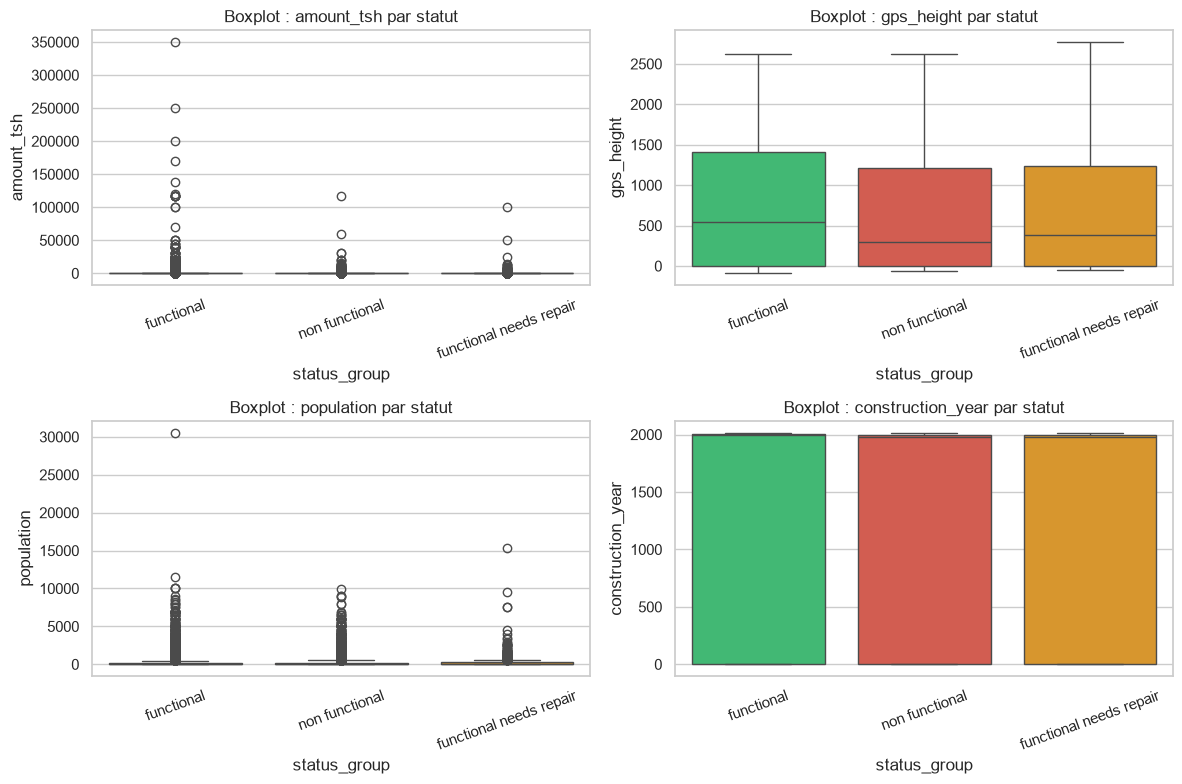

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, ["amount_tsh", "gps_height", "population", "construction_year"]):
 sns.boxplot(data=df_train, x="status_group", y=col, ax=ax, palette=colors, hue="status_group", legend=False)
 ax.set_title(f"Boxplot : {col} par statut")
 ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [8]:
anomalies = {
 "longitude = 0 (GPS invalide)": (df_train["longitude"] == 0).sum(),
 "latitude = 0": (df_train["latitude"] == 0).sum(),
 "construction_year = 0": (df_train["construction_year"] == 0).sum(),
 "gps_height < 0": (df_train["gps_height"] < 0).sum(),
 "amount_tsh = 0": (df_train["amount_tsh"] == 0).sum(),
}
anomaly_df = pd.DataFrame.from_dict(anomalies, orient="index", columns=["count"])
anomaly_df["pct"] = (anomaly_df["count"] / len(df_train) * 100).round(1)
display(anomaly_df)

,count,pct
longitude = 0 (GPS invalide),1812,3.1
latitude = 0,0,0.0
construction_year = 0,20709,34.9
gps_height < 0,1496,2.5
amount_tsh = 0,41639,70.1


**Analyse :**
- **`amount_tsh = 0`** (~70 %) : ambigu : vrai zéro pour pompes gravitaires ou donnée manquante codée à 0.
- **`construction_year = 0`** (~35 %) : signifie « année inconnue », pas l'an 0.
- **`gps_height < 0`** (~2,5 %) : erreurs de saisie ; altitude impossible.
- **GPS `(0, 0)`** (~3 %) : coordonnées invalides (Golfe de Guinée), pas en Tanzanie.
- Les boxplots montrent que les pompes `non functional` tendent vers des `construction_year` plus anciens et des altitudes différentes.

## 5. Variables catégorielles (S1-05)

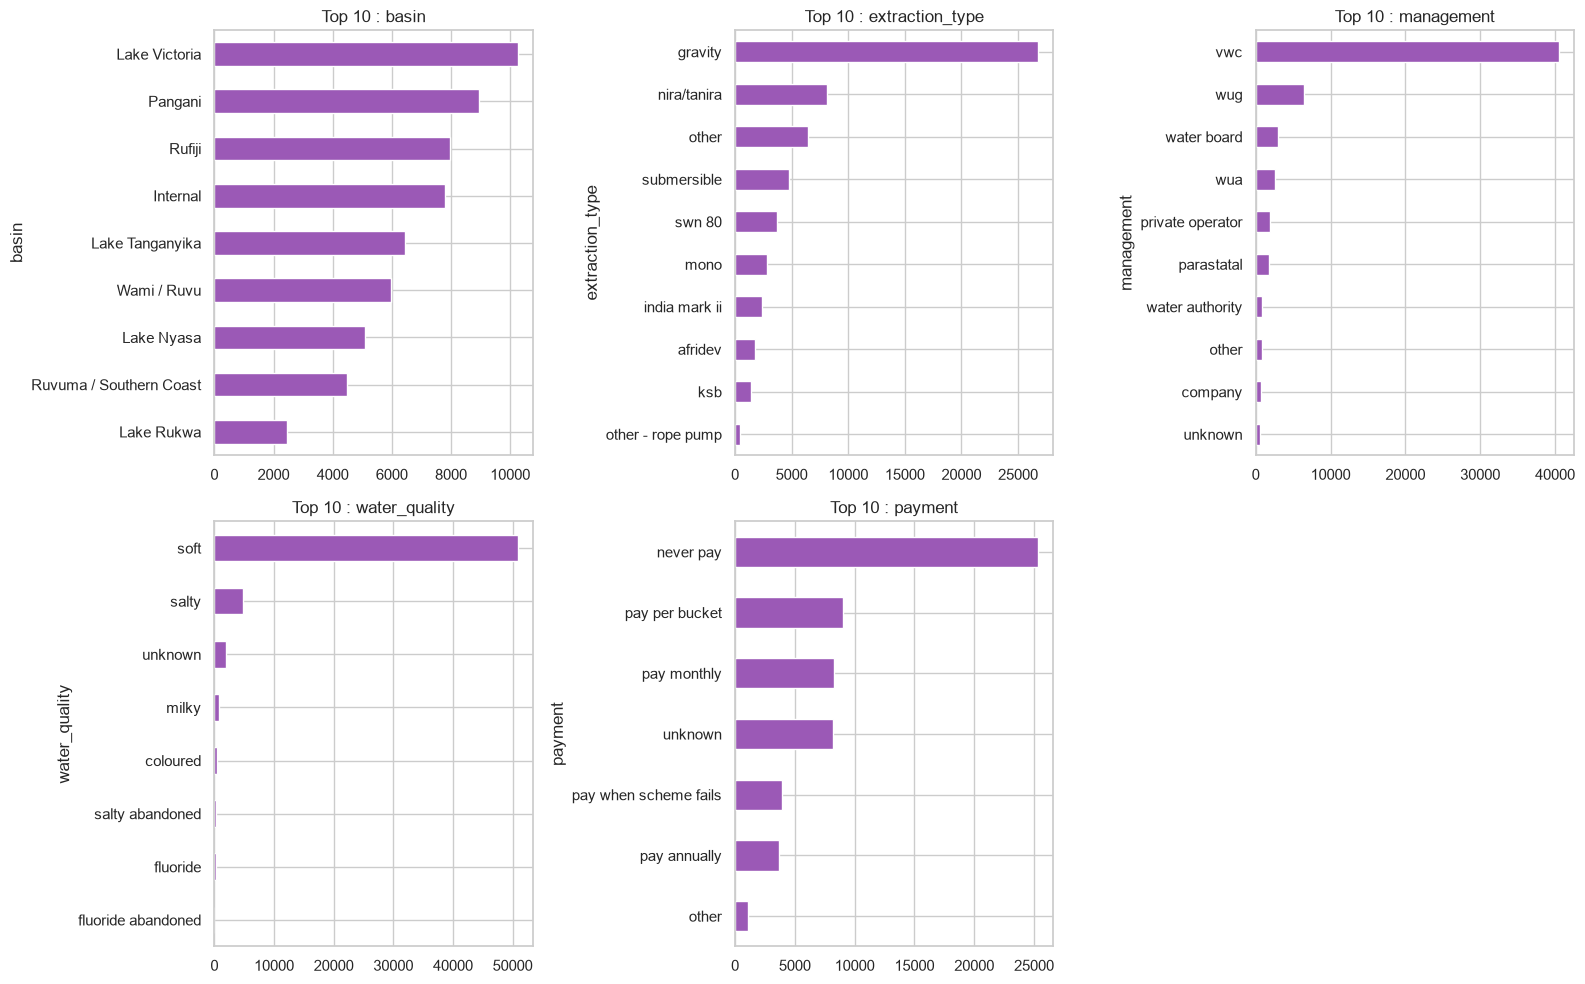

In [9]:
cat_cols = ["basin", "extraction_type", "management", "water_quality", "payment"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
 top = df_train[col].value_counts().head(10)
 top.plot.barh(ax=ax, color="#9b59b6", edgecolor="white")
 ax.set_title(f"Top 10 : {col}")
 ax.invert_yaxis()
axes[-1].axis("off")
plt.tight_layout()
plt.show()

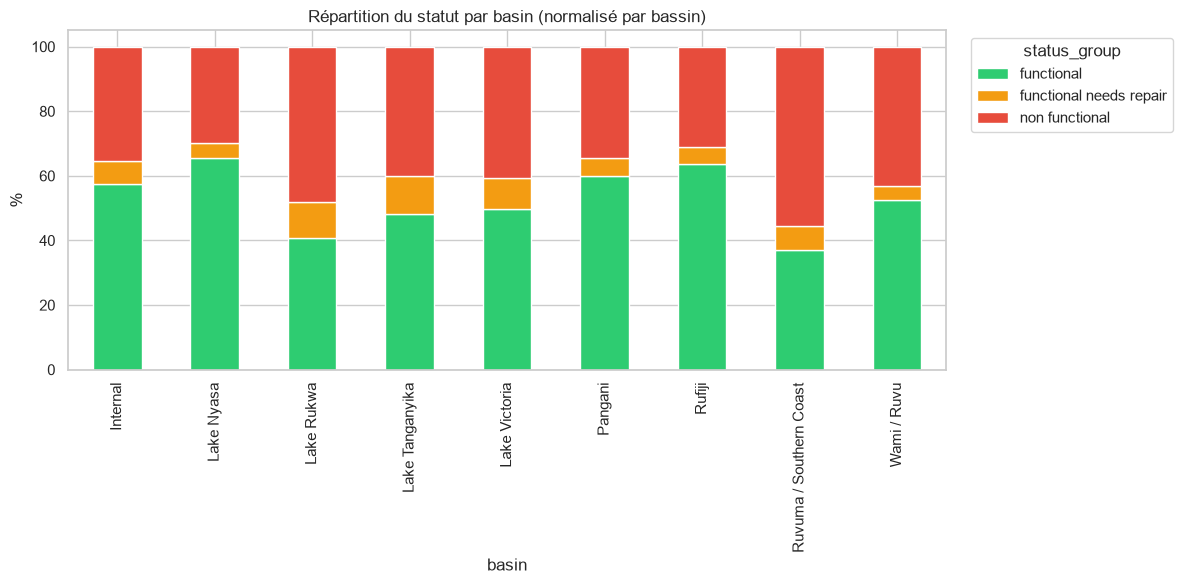

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ct = pd.crosstab(df_train["basin"], df_train["status_group"], normalize="index") * 100
ct.plot.bar(stacked=True, ax=ax, color=[colors[c] for c in ct.columns], edgecolor="white")
ax.set_title("Répartition du statut par basin (normalisé par bassin)")
ax.set_ylabel("%")
ax.legend(title="status_group", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Analyse :**
- `basin` regroupe les pompes en ~9 bassins versants : forte variation du taux de panne selon le bassin.
- `extraction_type` (handpump, motorised…) et `management` (vwc, wug…) sont des prédicteurs métier connus.
- `water_quality` et `payment` (payant vs gratuit) corrèlent avec l'entretien et donc le statut.

## 6. Analyse géographique (S1-06)

Pompes avec GPS valide : 57,588 / 59,400


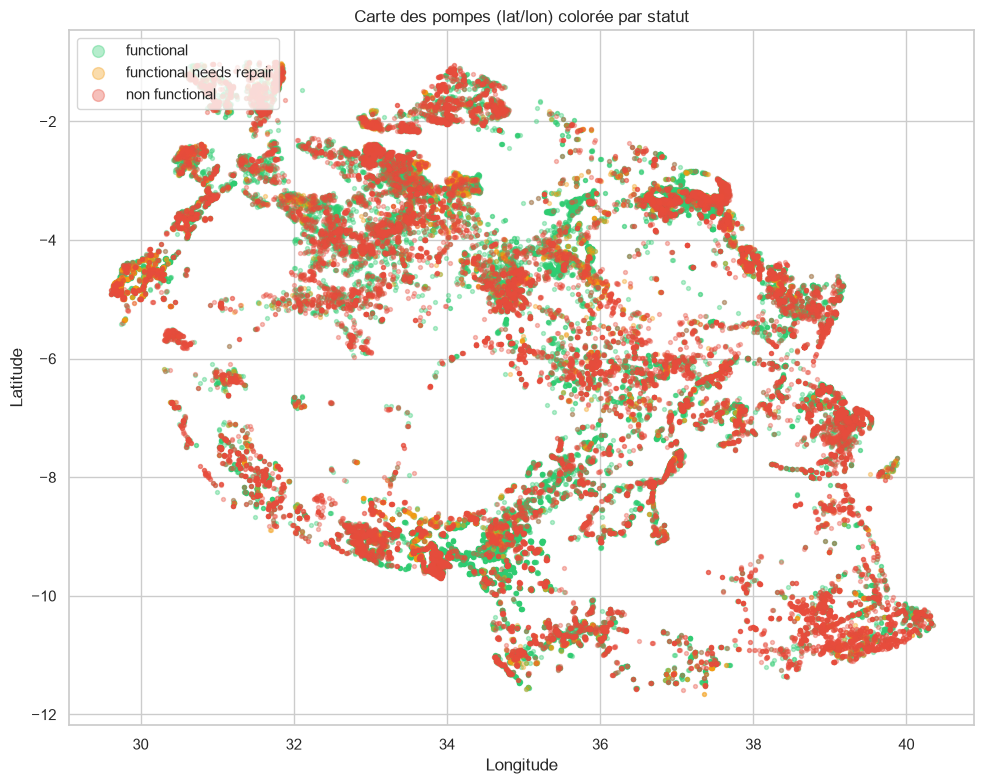

In [11]:
geo = df_train[(df_train["longitude"] != 0) & (df_train["latitude"] != 0)].copy()
print(f"Pompes avec GPS valide : {len(geo):,} / {len(df_train):,}")

fig, ax = plt.subplots(figsize=(10, 8))
for status, group in geo.groupby("status_group"):
 ax.scatter(
 group["longitude"],
 group["latitude"],
 s=8,
 alpha=0.35,
 label=status,
 c=colors[status],
 )
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Carte des pompes (lat/lon) colorée par statut")
ax.legend(markerscale=3, loc="upper left")
plt.tight_layout()
plt.show()

**Analyse :** les données couvrent la Tanzanie (origine du proxy). La logique géographique (clusters, isolement rural) est **transposable** au Maroc. Feature `dist_to_basin_center` créée en S2.

## 7. Matrice de corrélation (S1-07)

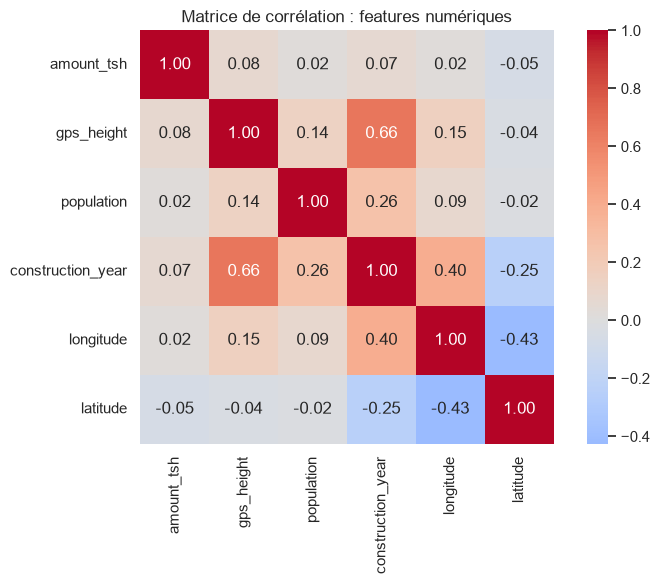

In [12]:
corr_cols = [
 "amount_tsh",
 "gps_height",
 "population",
 "construction_year",
 "longitude",
 "latitude",
]
corr = df_train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Matrice de corrélation : features numériques")
plt.tight_layout()
plt.show()

**Analyse :** pas de corrélation linéaire extrême (> 0,9) entre les numériques. On confirme en S2 la suppression de colonnes quasi-dupliquées (`quantity_group` ≈ `quantity`, etc.) plutôt que des paires numériques.

## 8. Analyse temporelle (S1-08)

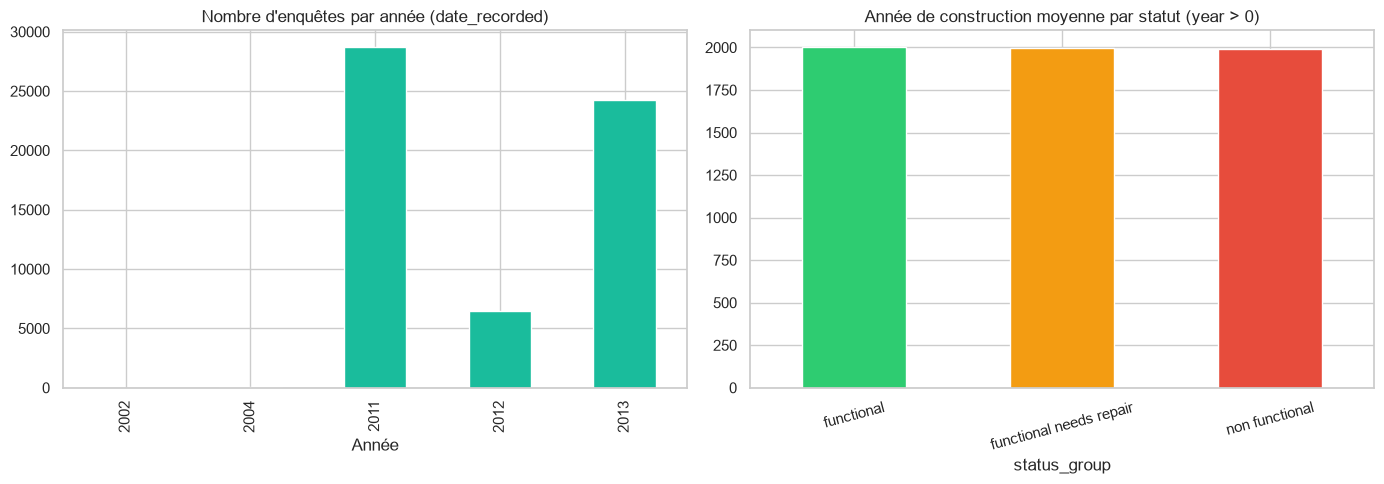

In [13]:
df_train["date_recorded"] = pd.to_datetime(df_train["date_recorded"], errors="coerce")
df_train["year_recorded"] = df_train["date_recorded"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train["year_recorded"].value_counts().sort_index().plot.bar(
 ax=axes[0], color="#1abc9c", edgecolor="white"
)
axes[0].set_title("Nombre d'enquêtes par année (date_recorded)")
axes[0].set_xlabel("Année")

valid_year = df_train[df_train["construction_year"] > 0]
valid_year.groupby("status_group")["construction_year"].mean().plot.bar(
 ax=axes[1], color=[colors[s] for s in valid_year.groupby("status_group")["construction_year"].mean().index],
 edgecolor="white",
)
axes[1].set_title("Année de construction moyenne par statut (year > 0)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

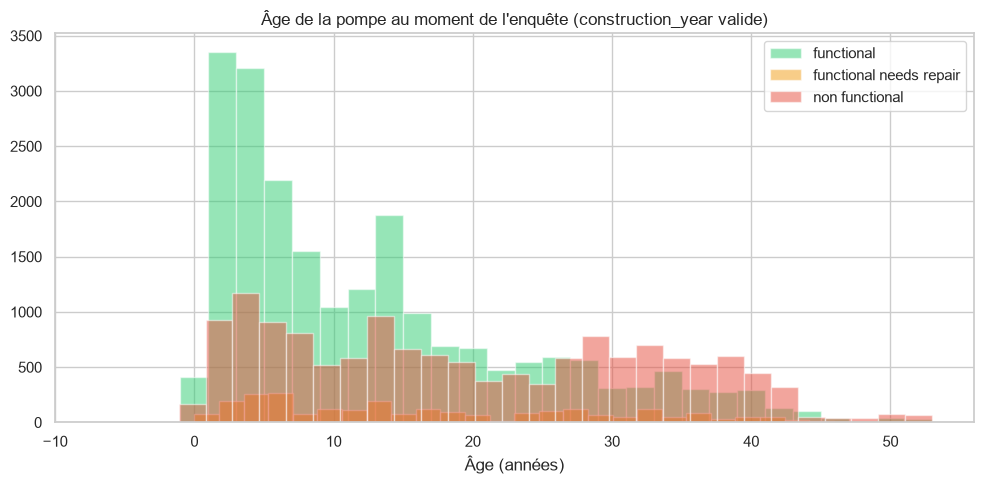

status_group
functional                 12.2
functional needs repair    17.2
non functional             19.8
Name: pump_age_at_survey, dtype: float64

In [14]:
valid_year = df_train[df_train["construction_year"] > 0].copy()
valid_year["pump_age_at_survey"] = valid_year["year_recorded"] - valid_year["construction_year"]

fig, ax = plt.subplots(figsize=(10, 5))
for status, group in valid_year.groupby("status_group"):
 group["pump_age_at_survey"].hist(ax=ax, bins=30, alpha=0.5, label=status, color=colors[status])
ax.set_title("Âge de la pompe au moment de l'enquête (construction_year valide)")
ax.set_xlabel("Âge (années)")
ax.legend()
plt.tight_layout()
plt.show()

valid_year.groupby("status_group")["pump_age_at_survey"].mean().round(1)

**Analyse :** les enquêtes couvrent principalement **2011-2013**. Les pompes `non functional` ont en moyenne un **âge plus élevé** au moment du survey : l'usure temporelle est un signal fort pour la maintenance prédictive.

## 9. Problem Statement (S1-09)

### Contexte Maroc
Le Maroc fait face à un **stress hydrique** : sécheresse, baisse des nappes, salinité en zones côtières et agricoles. En **zone rurale** (douars, communes isolées), des milliers de **forages et points d'eau** desservent des populations sans réseau urbain. Une pompe dégradée ou en panne peut priver des centaines de personnes d'eau potable. Les inspections terrain sont coûteuses et tardives.

### Choix du dataset d'entraînement
Faute de jeu marocain **ouvert et labellisé** à grande échelle (données ONEE/ABH sur demande), nous utilisons **Pump It Up** (Tanzanie, 59 400 pompes) comme **benchmark proxy** : structure analogue (forage, pompe, gestion, financement). Détail : `reports/choix_dataset_maroc.md`.

### Formulation technique
Étant donné un vecteur de features $\mathbf{x}$ décrivant une installation (géolocalisation, type d'extraction, financement, âge…), prédire $y \in \{\text{functional},\ \text{functional needs repair},\ \text{non functional}\}$.

### Critères métier
| Métrique | Cible | Justification |
|----------|-------|---------------|
| F1-Macro | ≥ 0,72 | Performance équilibrée sur les 3 classes |
| Recall `needs repair` | ≥ 0,65 | Ne pas rater les installations dégradées |

### Limites (rapport S9)
- Pas de mesure directe nappe/salinité (enjeux Maroc majeurs)
- Modèle entraîné sur géographie tanzanienne : transfert Maroc à documenter
- MQTT simulé en S6 : capteurs réels hors scope académique

## 10. Contexte methodologique (S1-10)

Historiquement, le diagnostic de pannes suivait une logique **rule-based** : des experts codifiaient des règles du type « si la pompe a plus de 20 ans ET le bassin est X -> probablement non functional ». Le système **MYCIN** (années 1970) illustrait cette approche en médecine : base de règles + chaînage avant/arrière, performant mais **non scalable** et difficile à maintenir sur des milliers de pompes hétérogènes.

Le **statistical learning** (puis le deep learning) remplace ces règles manuelles par des **patterns appris depuis les données**. Sur Pump It Up, XGBoost et Random Forest dominent souvent les benchmarks car les relations sont **non linéaires** et **interactionnelles** (basin × management × âge). Le deep learning apporte une valeur incertaine sur données tabulaires, mais reste à comparer honnêtement (S4-S5).

**Positionnement AquaSense AI :** combiner ML interprétable (feature importance) et pipeline de déploiement simulé (MQTT + dashboard) pour illustrer le passage de la **prédiction offline** à une **surveillance opérationnelle** : même si les capteurs sont simulés dans ce projet académique.

## 11. Catalogue des anomalies : synthèse EDA

In [15]:
catalog = pd.DataFrame(
 [
 ["scheme_name", "NaN", "~48,5 %", "Supprimer (quasi-vide)", "S2"],
 ["funder / installer", "NaN", "~6 %", "Imputer + top-20 + other", "S2"],
 ["longitude / latitude", "0.0", "~3 %", "Centroïde basin/région", "S2"],
 ["construction_year", "0", "~35 %", "Flag year_unknown + imputation", "S2"],
 ["gps_height", "< 0", "~2,5 %", "Imputation médiane basin", "S2"],
 ["amount_tsh", "= 0", "~70 %", "Flag tsh_is_zero + imputation", "S2"],
 ["quantity_group", "duplicata", "100 %", "Supprimer", "S2"],
 ["status_group", "imbalance", "7 % needs repair", "class_weight / SMOTE", "S3"],
 ],
 columns=["Colonne / sujet", "Type anomalie", "Volume", "Action prévue", "Sprint"],
)
display(catalog)

,Colonne / sujet,Type anomalie,Volume,Action prévue,Sprint
0,scheme_name,NaN,"~48,5 %",Supprimer (quasi-vide),S2
1,funder / installer,NaN,~6 %,Imputer + top-20 + other,S2
2,longitude / latitude,0.0,~3 %,Centroïde basin/région,S2
3,construction_year,0,~35 %,Flag year_unknown + imputation,S2
4,gps_height,< 0,"~2,5 %",Imputation médiane basin,S2
5,amount_tsh,= 0,~70 %,Flag tsh_is_zero + imputation,S2
6,quantity_group,duplicata,100 %,Supprimer,S2
7,status_group,imbalance,7 % needs repair,class_weight / SMOTE,S3


## 12. Résumé Sprint 1 : critères d'acceptation

| Critère | Statut |
|---------|--------|
| Notebook `01_eda.ipynb` complet | Oui |
| 8+ graphiques documentés | Oui (heatmap NaN, cible, 6 histo, 4 boxplots, 5 cat, carte geo, corrélation, 3 temporels) |
| Anomalies cataloguées | Oui section 11 |
| Stratégie imbalance définie | Oui section 3 |
| Problem Statement | Oui section 9 |
| Contexte methodologique | Oui section 10 |

**Prochaine étape :** Sprint 2 (wrangling) : déjà réalisé dans `src/preprocessing.py` - puis Sprint 3 (baseline ML).